## Importing the libraries

In [134]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

## Importing the dataset

In [135]:
dataset = pd.read_csv('Data_Heart_Attack_Detection_Model.csv')
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values
dataset.head()

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result
0,64,1,66,160,83,160.0,1.80,0.012,negative
1,21,1,94,98,46,296.0,6.75,1.060,positive
2,55,1,64,160,77,270.0,1.99,0.003,negative
3,64,1,70,120,55,270.0,13.87,0.122,positive
4,55,1,64,112,65,300.0,1.08,0.003,negative


## Visualizations of Variation of Independent variables with Result

Age Distribution

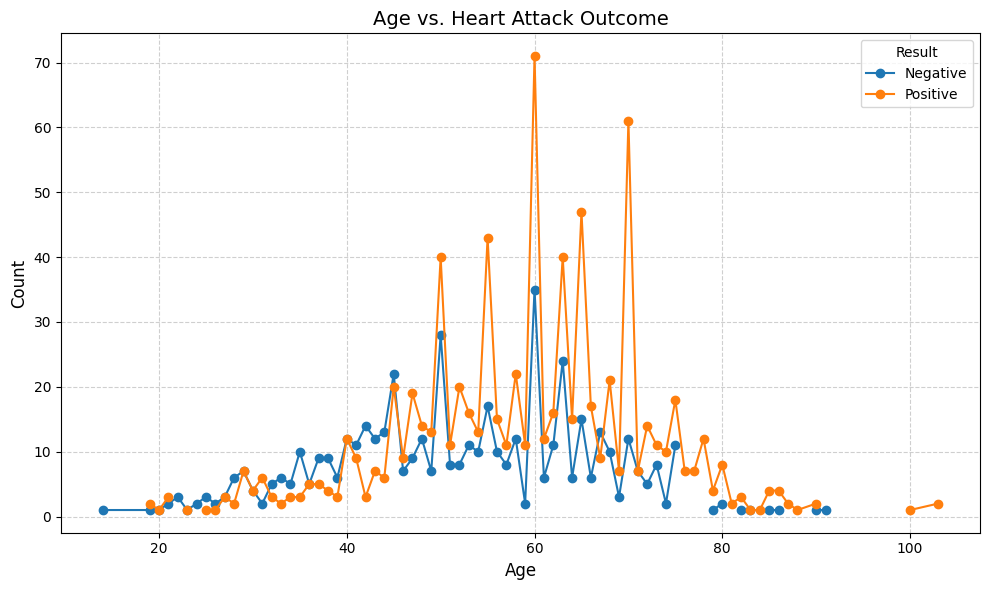

In [136]:
plt.figure(figsize=(10, 6))
age_distribution = dataset.groupby(['Age', 'Result']).size().unstack()
age_distribution.plot(kind='line', marker='o', ax=plt.gca(), figsize=(10, 6))
plt.title('Age vs. Heart Attack Outcome', fontsize=14)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(title='Result', labels=['Negative', 'Positive'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Gender Distribution

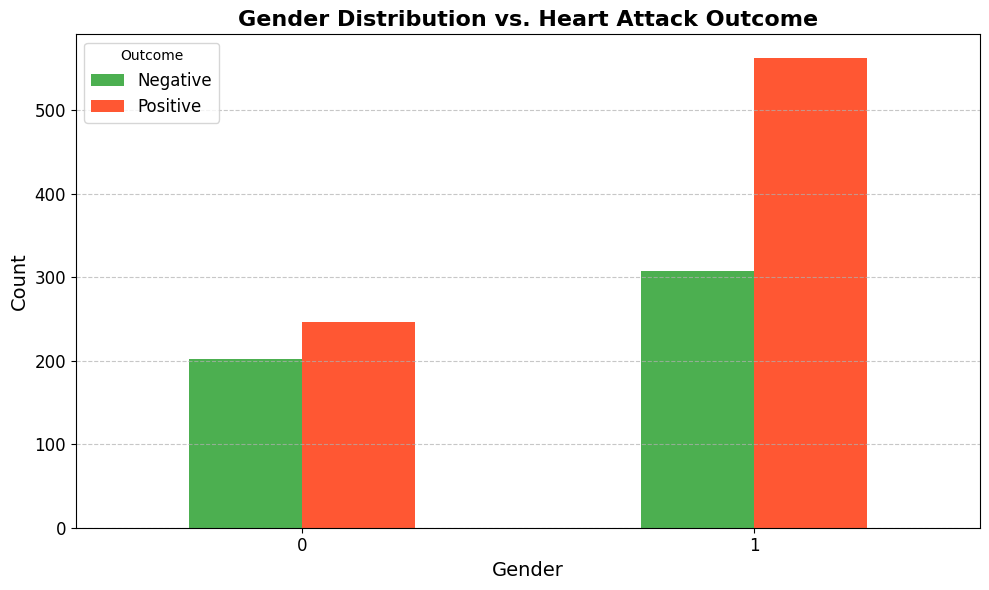

In [137]:
plt.figure(figsize=(10, 6))

gender_counts = dataset.groupby(['Gender', 'Result']).size().unstack().fillna(0)

ax = gender_counts.plot(kind='bar', stacked=False, ax=plt.gca(), figsize=(10, 6), color=['#4CAF50', '#FF5733'])

plt.title('Gender Distribution vs. Heart Attack Outcome', fontsize=16, fontweight='bold')
plt.xlabel('Gender', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(rotation=0, fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Outcome', labels=['Negative', 'Positive'], fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()


Heart Rate vs Result

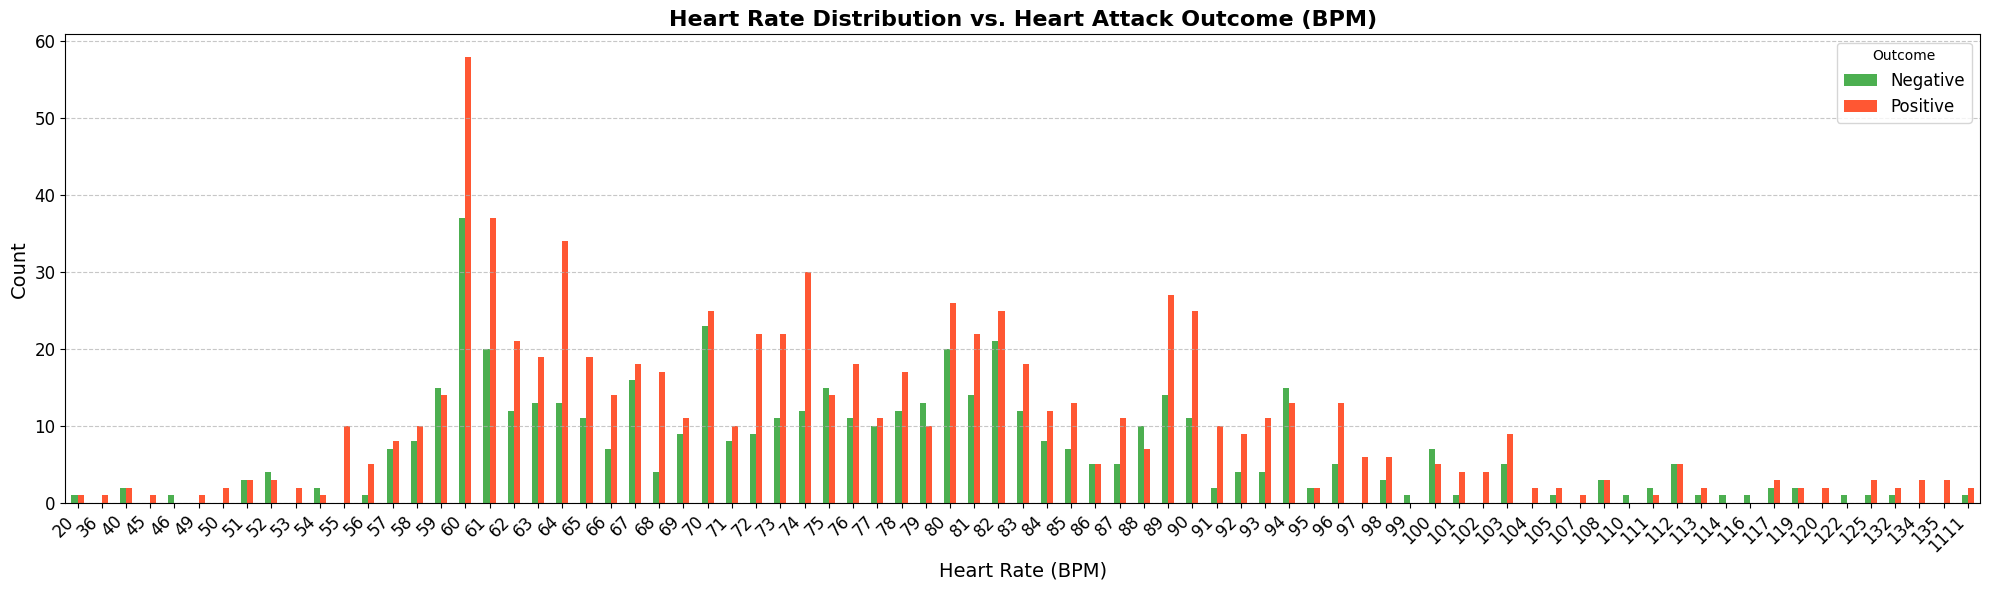

In [138]:
plt.figure(figsize=(20, 6))

heart_rate_counts = dataset.groupby(['Heart rate', 'Result']).size().unstack().fillna(0)

ax = heart_rate_counts.plot(kind='bar', stacked=False, ax=plt.gca(), figsize=(20, 6), color=['#4CAF50', '#FF5733'])

plt.title('Heart Rate Distribution vs. Heart Attack Outcome (BPM)', fontsize=16, fontweight='bold')
plt.xlabel('Heart Rate (BPM)', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Outcome', labels=['Negative', 'Positive'], fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()


Systolic and Diastolic BP Distribution

<Figure size 3500x600 with 0 Axes>

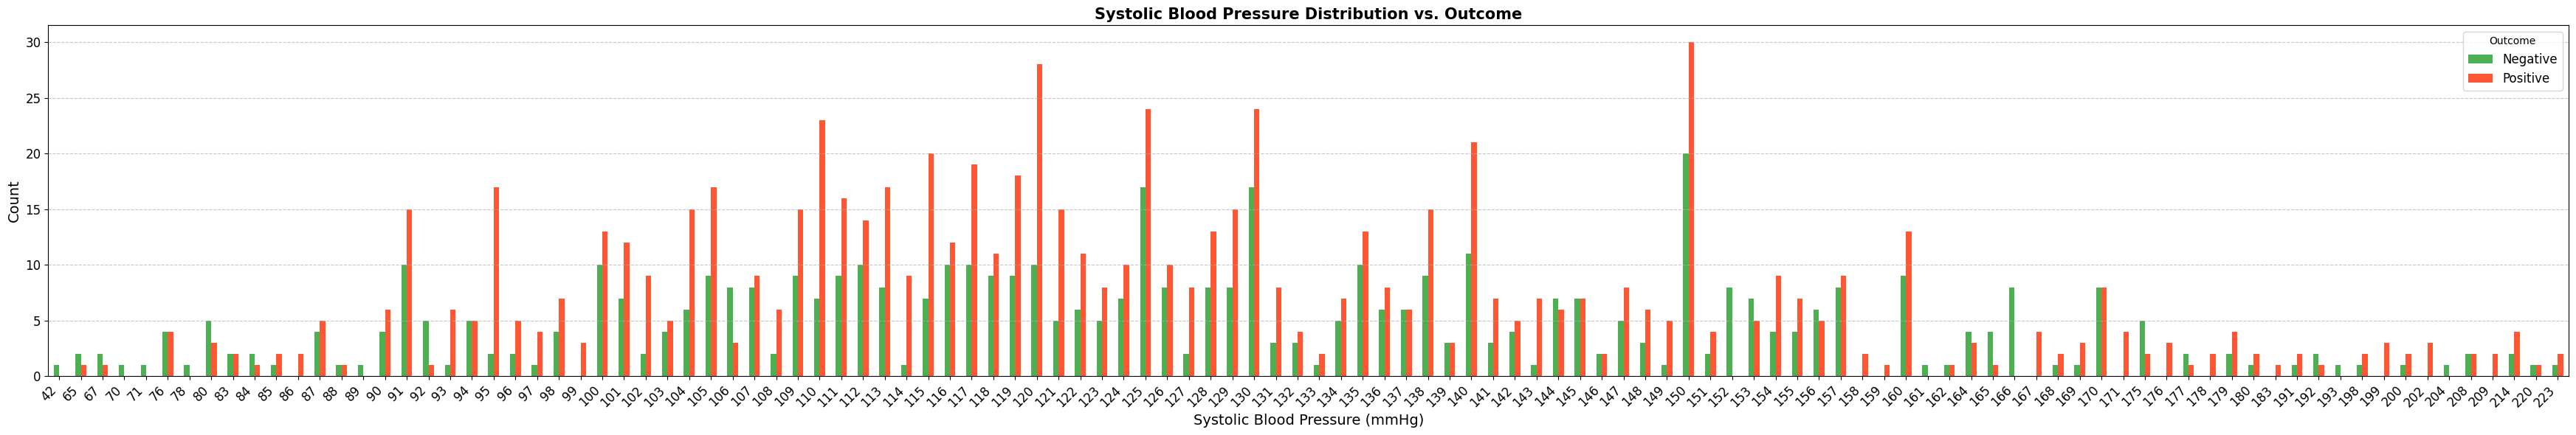

<Figure size 3500x600 with 0 Axes>

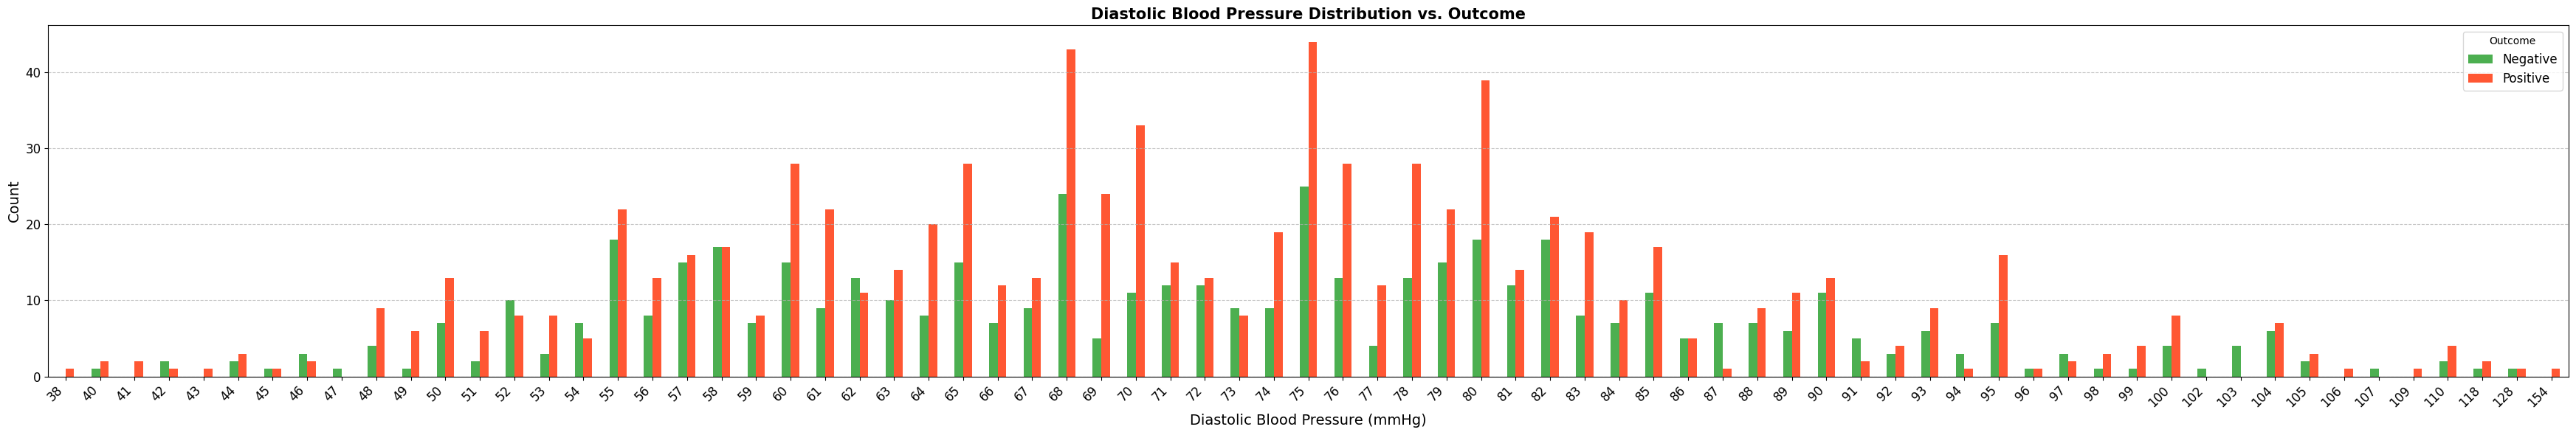

In [139]:
plt.figure(figsize=(35, 6))

blood_pressure_counts = dataset.groupby(['Systolic blood pressure', 'Result']).size().unstack().fillna(0)
blood_pressure_counts.plot(kind='bar', stacked=False, figsize=(35, 6), color=['#4CAF50', '#FF5733'])

plt.title('Systolic Blood Pressure Distribution vs. Outcome', fontsize=15, fontweight='bold')
plt.xlabel('Systolic Blood Pressure (mmHg)', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Outcome', labels=['Negative', 'Positive'], fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

plt.figure(figsize=(35, 6))

diastolic_bp_counts = dataset.groupby(['Diastolic blood pressure', 'Result']).size().unstack().fillna(0)
diastolic_bp_counts.plot(kind='bar', stacked=False, figsize=(35, 6), color=['#4CAF50', '#FF5733'])

plt.title('Diastolic Blood Pressure Distribution vs. Outcome', fontsize=15, fontweight='bold')
plt.xlabel('Diastolic Blood Pressure (mmHg)', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Outcome', labels=['Negative', 'Positive'], fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()


Blood Sugar Variation

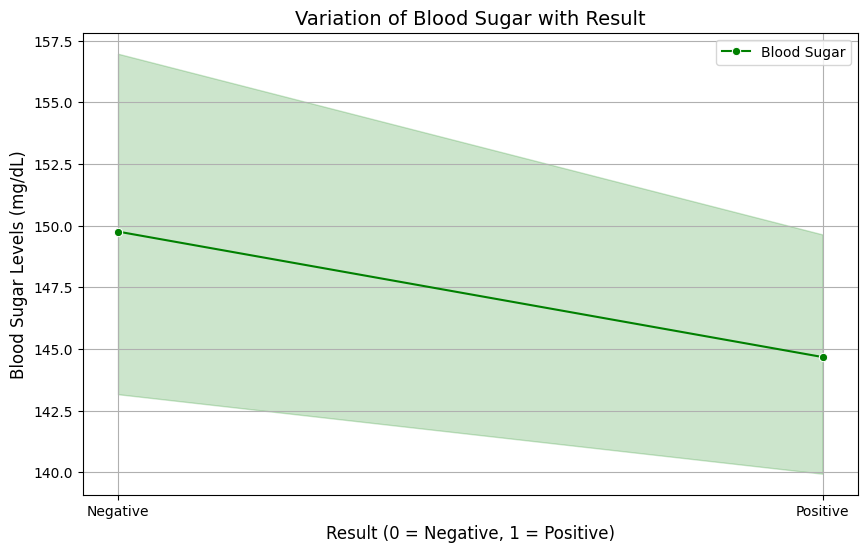

In [140]:
plt.figure(figsize=(10, 6))
sns.lineplot(x='Result', y='Blood sugar', data=dataset, marker='o', color='g', label='Blood Sugar')
plt.title('Variation of Blood Sugar with Result', fontsize=14)
plt.xlabel('Result (0 = Negative, 1 = Positive)', fontsize=12)
plt.ylabel('Blood Sugar Levels (mg/dL)', fontsize=12)
plt.xticks([0, 1], ['Negative', 'Positive'])
plt.grid(True)
plt.show()

CK-MB vs Result

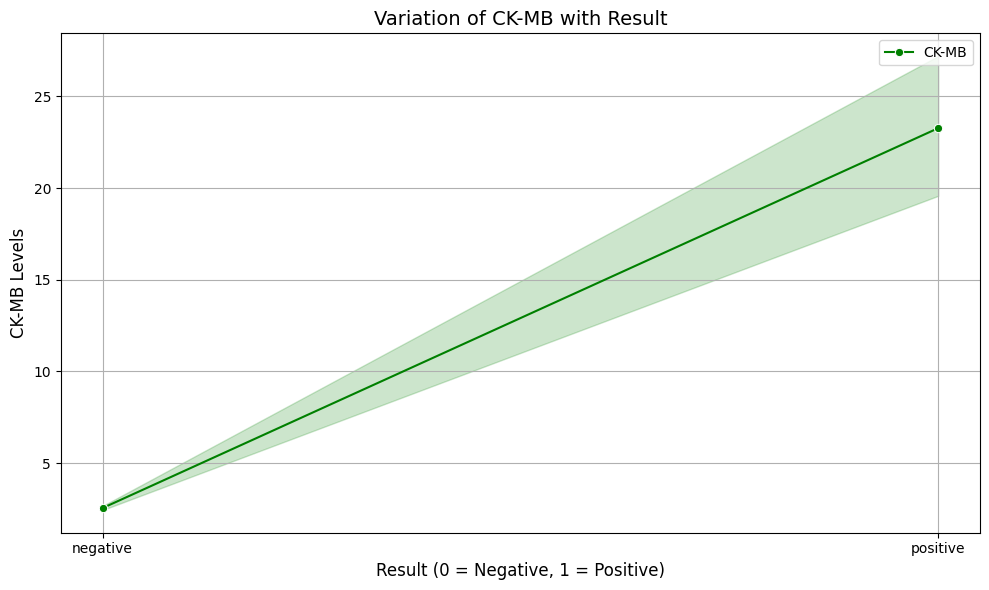

In [141]:
plt.figure(figsize=(10, 6))
sns.lineplot(x='Result', y='CK-MB', data=dataset, marker='o', color='g', label='CK-MB')
plt.title('Variation of CK-MB with Result', fontsize=14)
plt.xlabel('Result (0 = Negative, 1 = Positive)', fontsize=12)
plt.ylabel('CK-MB Levels', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

Troponin vs Result

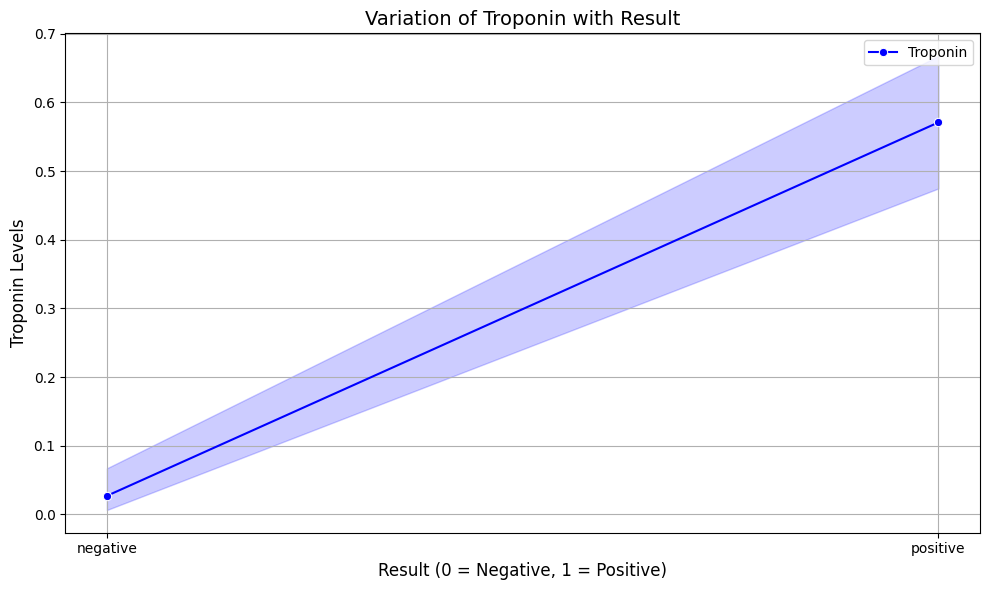

In [142]:
plt.figure(figsize=(10, 6))
sns.lineplot(x='Result', y='Troponin', data=dataset, marker='o', color='b', label='Troponin')
plt.title('Variation of Troponin with Result', fontsize=14)
plt.xlabel('Result (0 = Negative, 1 = Positive)', fontsize=12)
plt.ylabel('Troponin Levels', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

Systolic and Diastolic Blood Pressure variation

## Encoding the Dependent variable

In [143]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

## Splitting the dataset into the Training set and Test set

In [144]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

## Feature Scaling

In [145]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

## Training the Random Forest Classification model on the Training set

In [146]:
from sklearn.ensemble import RandomForestClassifier
classifier = RandomForestClassifier(n_estimators = 100, criterion = 'gini', random_state = 0)
classifier.fit(X_train, y_train)

RandomForestClassifier(random_state=0)

## Predicting the Test set results

In [147]:
y_pred = classifier.predict(X_test)
print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test.reshape(len(y_test),1)),1))

[[0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [1 0]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [1 1]

## Making the Confusion Matrix

In [148]:
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_test, y_pred)
print(cm)
print("Accuracy Score :", (accuracy_score(y_test, y_pred))*100, "%")

[[135   1]
 [  3 191]]
Accuracy Score : 98.7878787878788 %


## Predicting a new result

In [ ]:
age = int(input("Enter Age of patient : "))
gender = int(input("Enter Gender of patient [1 for Male | 0 for Female] : "))
heartRate = float(input("Enter Heart Rate of patient [BPM (Beats Per Minute)] : "))
sbp = float(input("Enter Systolic Blood Pressure of patient [mmHg] : "))
dbp = float(input("Enter Diastolic Blood Pressure of patient [mmHg] : "))
bloodSugar = float(input("Enter Blood Sugar of patient : "))
ckmb = float(input("Enter Creatine Kinase-Myoglobin Binding [CK-MB] of patient : "))
troponin = float(input("Enter Level of Troponin of patient : "))
msg1 = "| Very High Chance of Heart Attack |"
msg2 = "| Low Chance of Heart Attack |"
prediction = classifier.predict(sc.transform([[age, gender, heartRate, sbp, dbp, bloodSugar, ckmb, troponin]]))
if prediction == 1:
  print("\n")
  print("-"*len(msg1))
  print(msg1)
  print("-"*len(msg1))
elif prediction == 0:
  print("\n")
  print("-"*len(msg2))
  print(msg2)
  print("-"*len(msg2))